In [1]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE, AUC, NDCG, Precision, Recall
from cornac.models import MF, ItemKNN, UserKNN, NMF, BPR, LightGCN, SVD, MostPop, VAECF, NeuMF
import pandas as pd
import numpy as np
import random
# import matha
from collections import OrderedDict
import seaborn as sns
import matplotlib.pyplot as plt

/Users/tahsinalamgirkheya/anaconda3/envs/cornac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
reader = Reader()
rating_data_pd = pd.read_csv(
    "./cornac/data_c/yelp/indexed_interactions.csv",
    sep="\t",
    header=0,
    names=[ "itemID","Category", "userID","Rating", "Gender"],
)
rating_data = rating_data_pd[["userID", "itemID","Rating"]].to_numpy()
rating_data.__len__()
rating_data_pd


,itemID,Category,userID,Rating,Gender
0,0,Food & Restaurants|Drinks & Spirits,0,5,F
1,0,Food & Restaurants|Drinks & Spirits,1,4,F
2,0,Food & Restaurants|Drinks & Spirits,2,5,F
3,0,Food & Restaurants|Drinks & Spirits,3,3,M
4,0,Food & Restaurants|Drinks & Spirits,4,3,F
...,...,...,...,...,...
97986,1271,Food & Restaurants,1060,3,F
97987,1271,Food & Restaurants,161,2,M
97988,1271,Food & Restaurants,25,3,F
97989,1271,Food & Restaurants,280,4,F


In [3]:

restaurants = pd.read_csv("./cornac/data_c/yelp/i_id_mapping.csv",sep="\t",
    header=0,
    names=[ "item_id","Category","itemID"])
restaurants=restaurants.sort_values(by="itemID")

unique_categories = [
    "Active Life & Fitness",
    "Arts & Entertainment",
    "Automotive",
    "Bars & Nightlife",
    "Coffee,Tea & Desserts",
    "Drinks & Spirits",
    "Education & Learning",
    "Event Services",
    "Family & Kids",
    "Food & Restaurants",
    "Health & Beauty",
    "Home & Garden",
    "Miscellaneous",
    "Outdoor Activities",
    "Public Services & Community",
    "Shopping & Fashion",
    "Specialty Food & Groceries",
    "Sports & Recreation",
    "Technology & Electronics",
    "Travel & Transportation",
    "Asian",
]
for c in unique_categories:
    restaurants[c] = 0
for index, row in restaurants.iterrows():
    cats = row["Category"].split("|")
    for cat in cats:
        restaurants.at[index, cat] = 1

cat = restaurants[unique_categories]
# cat[:1]
item_features_numpy = cat.to_numpy()
item_features = {
    str(item_id): {"category_" + str(idx): value for idx, value in enumerate(row)}
    for item_id, row in enumerate(item_features_numpy)
}
# ids = list(range(0, 3416))

In [4]:
restaurants

,item_id,Category,itemID,Active Life & Fitness,Arts & Entertainment,Automotive,Bars & Nightlife,"Coffee,Tea & Desserts",Drinks & Spirits,Education & Learning,...,Home & Garden,Miscellaneous,Outdoor Activities,Public Services & Community,Shopping & Fashion,Specialty Food & Groceries,Sports & Recreation,Technology & Electronics,Travel & Transportation,Asian
0,34,Food & Restaurants|Drinks & Spirits,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,250,Food & Restaurants|Drinks & Spirits,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,759,Asian|Food & Restaurants,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1085,Food & Restaurants,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1122,Travel & Transportation,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1267,188255,Food & Restaurants,1267,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1268,188310,Food & Restaurants,1268,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1269,188449,Food & Restaurants|Bars & Nightlife,1269,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1270,188454,Food & Restaurants,1270,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:

users = pd.read_csv("./cornac/data_c/yelp/u_id_mapping.csv", sep="\t",header=0,
    names=[ "user_id","Gender","userID"])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
users = users.sort_values(by="userID")
users = users[["Gender", "userID"]]

user_features_numpy = users.to_numpy()
print(user_features_numpy.shape)
# print(item_features_numpy.shape)

(1316, 2)


In [6]:
# users
user_features_numpy[:,1]

array([   0,    1,    2, ..., 1313, 1314, 1315])

In [7]:
dataset = rating_data
unique_categories.__len__()

21

In [9]:
rec_50 = cornac.metrics.Recall(k=50)
ndcg_50 = cornac.metrics.NDCG(k=50)
auc = cornac.metrics.AUC()
prec = cornac.metrics.Precision(k=50)
hr = cornac.metrics.HitRatio(k=50)
mrr = cornac.metrics.MRR()
map = cornac.metrics.MAP()
f1 = cornac.metrics.FMeasure(k=50)
ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    rating_threshold=0,
    val_size=0.1,
    seed=123,
    verbose=True,
    user_features=user_features_numpy[:, 0],
    item_features=item_features_numpy,
    exclude_unknowns=False,fmt="UIR"
)
models = []
x=[]
alpha_values = [0,0.1,0.2, 0.3, 0.4, 0.5, 0.6 ]
# alpha_values = [0]
for i in range(len(alpha_values)):
    # learning
    models.append(
        MF(
            k=20,
            seed=123,
            name=f"a={alpha_values[i]} mf",
            backend="pytorch",
            verbose=True,
            optimizer="adam",batch_size=128,
            alpha=alpha_values[i],
            learning_rate=0.001,
            top_k=50, max_iter=15,run_mode="bce",
            # early_stopping=True
        )
    )
# Early stopping:
# - best epoch = 5, stopped epoch = 15
# - best monitored value = 0.062177 (delta = 0.000021)
 

cornac.Experiment(
    ratio_split, models=models, metrics=[rec_50, ndcg_50, auc, prec, hr, mrr, map, f1]
).run()


rating_threshold = 0.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
(array([   0,    0,    0, ..., 1315, 1315, 1315]), array([   0,    1,    2, ..., 1030,  793, 1250]), array([4., 5., 2., ..., 4., 5., 5.]))
Number of users = 1316
Number of items = 1272
Number of ratings = 67470
Max rating = 5.0
Min rating = 1.0
Global mean = 3.9
Global mean Imolicit= 1.0
::::::::
OrderedDict([(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6), (7, 7), (8, 8), (9, 9), (10, 10), (11, 11), (12, 12), (13, 13), (14, 14), (15, 15), (16, 16), (17, 17), (18, 18), (19, 19), (20, 20), (21, 21), (22, 22), (23, 23), (24, 24), (25, 25), (26, 26), (27, 27), (28, 28), (29, 29), (30, 30), (31, 31), (32, 32), (33, 33), (34, 34), (35, 35), (36, 36), (37, 37), (38, 38), (39, 39), (40, 40), (41, 41), (42, 42), (43, 43), (44, 44), (45, 45), (46, 46), (47, 47), (48, 48), (49, 49), (50, 50), (51, 51), (52, 52), (53, 53), (54, 54), (55, 55), (56, 56), (57, 57), (58, 58), (59, 5

100%|██████████| 15/15 [01:10<00:00,  4.68s/it, loss=0.607]


[88.72200012207031, 88.71958923339844, 88.71334838867188, 88.69508361816406, 88.69140625, 88.69329833984375, 88.67759704589844, 88.71459197998047, 88.69583892822266, 88.6820297241211, 88.68392181396484, 88.68724060058594, 88.65498352050781, 88.63636016845703, 88.688232421875, 88.65079498291016, 88.67729949951172, 88.6888427734375, 88.66476440429688, 88.63992309570312, 88.68098449707031, 88.58064270019531, 88.66690063476562, 88.59637451171875, 88.65257263183594, 88.61607360839844, 88.63516235351562, 88.65868377685547, 88.60594177246094, 88.6719741821289, 88.58411407470703, 88.65142059326172, 88.59136199951172, 88.55110168457031, 88.60997772216797, 88.61339569091797, 88.60411834716797, 88.5596923828125, 88.69534301757812, 88.52542877197266, 88.53880310058594, 88.52909851074219, 88.50550079345703, 88.57130432128906, 88.57186889648438, 88.5130844116211, 88.6603012084961, 88.46080017089844, 88.56851196289062, 88.47997283935547, 88.56163024902344, 88.42633056640625, 88.52561950683594, 88.669

Ranking: 100%|██████████| 1316/1316 [00:02<00:00, 556.28it/s]



[a=0.1 mf] Training started!


...


[a=0.6 mf] Training started!


100%|██████████| 15/15 [03:29<00:00, 13.94s/it, loss=0.484]


[61.64938735961914, 61.562747955322266, 61.544227600097656, 61.555965423583984, 61.56708908081055, 61.60129928588867, 61.58501434326172, 61.62493133544922, 61.66474914550781, 61.60011672973633, 61.66526794433594, 61.70958709716797, 61.65571212768555, 61.67839050292969, 61.69635772705078, 61.69010543823242, 61.73309326171875, 61.684349060058594, 61.7576904296875, 61.705535888671875, 61.81636047363281, 61.69609832763672, 61.721229553222656, 61.70124053955078, 61.83257293701172, 61.75336837768555, 61.6994514465332, 61.78272247314453, 61.79573059082031, 61.80730438232422, 61.75712203979492, 61.82942199707031, 61.743831634521484, 61.81568908691406, 61.7689208984375, 61.840797424316406, 61.90670394897461, 61.87104797363281, 61.95350646972656, 61.755287170410156, 61.65947723388672, 61.79865264892578, 61.728843688964844, 61.750953674316406, 61.79255676269531, 61.863121032714844, 61.97828674316406, 61.76575469970703, 61.896453857421875, 61.83538055419922, 61.95659637451172, 61.90343475341797, 6

Ranking: 100%|██████████| 1316/1316 [00:01<00:00, 1110.62it/s]


VALIDATION:
...
         |    AUC |  F1@50 | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Time (s)
-------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------
a=0 mf   | 0.6837 | 0.0420 |      0.6786 | 0.0391 | 0.1334 |  0.0924 |       0.0254 |    0.1603 |   2.3705
a=0.1 mf | 0.6751 | 0.0417 |      0.6854 | 0.0372 | 0.1268 |  0.0905 |       0.0252 |    0.1595 |   0.7497
a=0.2 mf | 0.6558 | 0.0378 |      0.6482 | 0.0345 | 0.1221 |  0.0824 |       0.0229 |    0.1435 |   1.1228
a=0.3 mf | 0.6376 | 0.0308 |      0.5691 | 0.0303 | 0.1065 |  0.0679 |       0.0186 |    0.1171 |   1.1092
a=0.4 mf | 0.5965 | 0.0249 |      0.4985 | 0.0205 | 0.0629 |  0.0483 |       0.0151 |    0.0938 |   1.2873
a=0.5 mf | 0.5630 | 0.0192 |      0.4111 | 0.0166 | 0.0470 |  0.0358 |       0.0116 |    0.0718 |   1.5482
a=0.6 mf | 0.5554 | 0.0182 |      0.4088 | 0.0162 | 0.0475 |  0.0355 |       0.0110 |    0.0702 |   1.1881

TEST:
...
         

In [10]:
user_ids = users.to_numpy()[:, 1]
item_ids = restaurants.to_numpy()[:, 2]
print(len(user_ids))
print(len(item_ids))
print(user_ids)
print(item_ids)

1316
1272
[   0    1    2 ... 1313 1314 1315]
[0 1 2 ... 1269 1270 1271]


In [11]:
# models[0].save("./saved")
import pickle

with open('mf100kyelp_gr.pkl', 'wb') as f:
    # Pickle the 'data' dictionary using the highest protocol available.
    pickle.dump(models, f, pickle.HIGHEST_PROTOCOL)


In [12]:
user_ids = users.to_numpy()[:, 1]
item_ids = restaurants.to_numpy()[:, 2]
item_ids.__len__()
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(models), len(user_ids), top_k), dtype=int)
reco_matrix_mapped_items = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=int
)
reco_matrix_mapped_scores = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=float
)
reco_matrix_all = np.zeros((len(models), len(user_ids), len(item_ids)), dtype=int)


for u in user_ids:
    for i in range(len(models)):
        reco_items = models[i].recommend(u)
        items_mapped, mapped_scores = models[i].rank(
            user_idx=u, item_indices=list(item_ids)
        )
        reco_matrix_mapped_items[i][u] = items_mapped
        reco_matrix_mapped_scores[i][u] = mapped_scores
        reco_matrix_all[i][u] = reco_items
        reco_matrix[i][u] = reco_items[:top_k]

        # print(reco_matrix[0][3])

In [13]:
np.save("reco_matrix_mf_yelp_100k_gr.npy", reco_matrix)
# np.save("reco_matrix_mapped_items.npy", reco_matrix_mapped_items)
# np.save("reco_matrix_mapped_scores.npy", reco_matrix_mapped_scores)
np.save("reco_matrix_all_mf_yelp_100k_gr.npy", reco_matrix_all)
# np.save("reco_items_scores_all.npy", reco_items_scores_all)

# reco_matrix_all_items

In [14]:

def extract_columns(table: str, col_names: tuple):
    """
    Extract columns named in col_names from the ASCII table in `table`.
    Returns list of lists corresponding to each column.
    """
    lines = [ln for ln in table.splitlines() if ln.strip() != ""]
    # find header line (contains known header tokens like 'RMSE' or 'HitRatio')
    header_idx = None
    for i, ln in enumerate(lines):
        if 'AUC' in ln and 'HitRatio' in ln:
            header_idx = i
            break
    if header_idx is None:
        raise ValueError("Header line not found in table")

    # find separator line after header (line with dash or +)
    sep_idx = None
    for j in range(header_idx+1, len(lines)):
        if set(lines[j].strip()) <= set("-+ "):
            sep_idx = j
            break
    if sep_idx is None:
        # fallback: assume header_idx is followed immediately by data
        sep_idx = header_idx

    header_line = lines[header_idx]
    data_lines = lines[sep_idx+1:]

    # split header into column names
    headers = [h.strip() for h in header_line.split('|')]
    # find indices for requested columns
    idxs = []
    for cname in col_names:
        try:
            idx = headers.index(cname)
        except ValueError:
            # try more tolerant matching (case-insensitive / substring)
            found = False
            for k, h in enumerate(headers):
                if cname.lower() in h.lower():
                    idxs.append(k)
                    found = True
                    break
            if not found:
                raise ValueError(f"Column '{cname}' not found in header: {headers}")
        else:
            idxs.append(idx)

    # parse data rows
    results = [[] for _ in col_names]
    for dl in data_lines:
        parts = [p.strip() for p in dl.split('|')]
        # skip lines that don't have enough columns
        if len(parts) <= max(idxs):
            continue
        for out_list, idx in zip(results, idxs):
            val_str = parts[idx]
            # remove accidental commas and convert to float
            try:
                val = float(val_str.replace(',', ''))
            except ValueError:
                # if there are extra spaces or non-numeric, try to extract numeric substring
                import re
                m = re.search(r"[-+]?\d*\.\d+|\d+", val_str)
                if m:
                    val = float(m.group(0))
                else:
                    raise
            out_list.append(val)
    return results



In [15]:
perf_string = """
          |    AUC |  F1@50 | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
-------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
a=0 mf   | 0.6842 | 0.0713 |      0.8587 | 0.0558 | 0.2198 |  0.1209 |       0.0495 |    0.1621 |   70.2371 |   2.1815
a=0.1 mf | 0.6755 | 0.0723 |      0.8640 | 0.0559 | 0.2149 |  0.1229 |       0.0500 |    0.1651 |  244.7922 |   0.8739
a=0.2 mf | 0.6574 | 0.0663 |      0.8397 | 0.0509 | 0.2015 |  0.1121 |       0.0458 |    0.1520 |  210.5092 |   1.2668
a=0.3 mf | 0.6385 | 0.0532 |      0.7903 | 0.0401 | 0.1565 |  0.0856 |       0.0370 |    0.1212 |  282.8929 |   1.4091
a=0.4 mf | 0.5961 | 0.0420 |      0.7264 | 0.0298 | 0.1048 |  0.0621 |       0.0292 |    0.0955 |  232.0557 |   1.6285
a=0.5 mf | 0.5636 | 0.0320 |      0.6375 | 0.0252 | 0.0904 |  0.0481 |       0.0222 |    0.0728 |  270.3504 |   1.6575
a=0.6 mf | 0.5551 | 0.0303 |      0.6246 | 0.0240 | 0.0831 |  0.0457 |       0.0209 |    0.0691 |  209.1078 |   1.3431
"""
hit_list, ndcg_list = extract_columns(perf_string, ("HitRatio@50", "NDCG@50"))
print("HitRatio@50:", hit_list)
print("NDCG@50:   ", ndcg_list)

HitRatio@50: [0.8587, 0.864, 0.8397, 0.7903, 0.7264, 0.6375, 0.6246]
NDCG@50:    [0.1209, 0.1229, 0.1121, 0.0856, 0.0621, 0.0481, 0.0457]


In [16]:
####Import Metrics####
from cornac.mymetrics.GenrePrecision import GenrePrecision
from cornac.mymetrics.GenreMapEdited import GenreMapEdited
from cornac.mymetrics.GenreMRR import GenreMRR
from cornac.mymetrics.GenreNDCG import GenreNDCG
from cornac.mymetrics.GenreRecall import GenreRecall
from cornac.mymetrics.GenreRPrecision import GenreRPrecision


top_k = 50
###intialize them
gp = GenrePrecision(users, unique_categories, top_k)
gr = GenreRecall(users, unique_categories, top_k)
gm = GenreMapEdited(users, unique_categories, top_k)
gndcg = GenreNDCG(users, unique_categories, top_k)
gmrr = GenreMRR(users, unique_categories, top_k)

In [17]:
####IR Metrics####
model_gps = []
model_grs = []
model_gms = []
model_gdcgs = []
model_gmrrs = []

for i in range(len(reco_matrix)):
    ####Precision####
    model_gps.append(gp.compute(reco_matrix[i], restaurants))
    model_grs.append(gr.compute(reco_matrix[i], restaurants))
    model_gms.append(gm.compute(reco_matrix[i], restaurants))
    model_gdcgs.append(gndcg.compute(reco_matrix[i], restaurants))
    model_gmrrs.append(gmrr.compute(reco_matrix[i], restaurants))


restaurants = restaurants.rename(columns={"Category": "genres"})
# ####IR Metrics####
# ####Rprecision####
model_grps = []
# for i in range(len(models)):
#     model_grps.append(grp.compute(reco_matrix_top_r[i], restaurants_df, restaurants))


In [18]:
# for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
movies_df = restaurants[unique_categories].div(restaurants[unique_categories].sum(axis=1), axis=0)
movies_df = movies_df[unique_categories].sum()
import math
new_top_k = math.floor(movies_df.max())


# get the top_k ratings for all users:
reco_matrix_top_r = np.zeros((len(reco_matrix), len(user_ids), new_top_k), dtype=int)

for u in range(len(user_ids)):
    for i in range(len(reco_matrix)):
        # reco_items, all_scores = models[i].rank(user_idx=user_ids[i], item_indices=list(item_ids))
        reco_matrix_top_r[i][u] = reco_matrix_all[i][u][:new_top_k]


grp = GenreRPrecision(users, unique_categories, top_k)
# MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [19]:
model_grps = []
for i in range(len(reco_matrix)):
    model_grps.append(grp.compute(reco_matrix_top_r[i], movies_df, restaurants))

        Active Life & Fitness  Arts & Entertainment  Automotive  \
Gender                                                            
0                    0.000025              0.065723         0.0   
1                    0.000019              0.059726         0.0   

        Bars & Nightlife  Coffee,Tea & Desserts  Drinks & Spirits  \
Gender                                                              
0               0.103505               0.046771          0.013744   
1               0.102316               0.049948          0.013796   

        Education & Learning  Event Services  Family & Kids  \
Gender                                                        
0                        0.0        0.031856            0.0   
1                        0.0        0.028954            0.0   

        Food & Restaurants  ...  Home & Garden  Miscellaneous  \
Gender                      ...                                 
0                 0.535669  ...            0.0            0.0   
1     

In [20]:
gp_sum = [sum(abs(model_gps[i])) for i in range(len(reco_matrix))]
gr_sum = [sum(abs(model_grs[i])) for i in range(len(reco_matrix))]
gm_sum = [sum(abs(model_gms[i])) for i in range(len(reco_matrix))]
gdcg_sum = [sum(abs(model_gdcgs[i])) for i in range(len(reco_matrix))]
gmrr_sum = [sum(abs(model_gmrrs[i])) for i in range(len(reco_matrix))]
grp_sum = [sum(abs(model_grps[i])) for i in range(len(reco_matrix))]


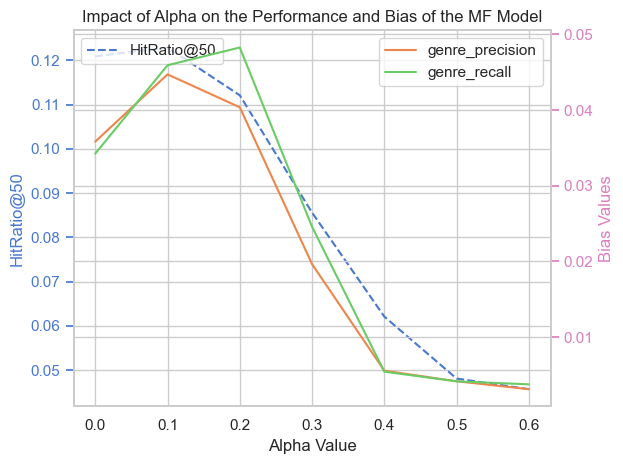

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

alpha_values = [0, 0.1,0.2,0.3,0.4,0.5,0.6]

x = alpha_values
upper_bound = len(alpha_values)
titles = [
    "genre_precision",
    "genre_recall",
    "genre_map",
    "genre_dcg",
    "genre_mrr",
    "genre_r_precision",
]
sns.set(style="whitegrid")
pastel_palette = sns.color_palette("muted")

fig, ax1 = plt.subplots()

ax1.plot(x[0:upper_bound], ndcg_list[0:upper_bound], linestyle="--", color=pastel_palette[0], label="HitRatio@50")
# ax1.plot(x[0:upper_bound], auc_values_extracted[0:upper_bound], linestyle="dotted", color=pastel_palette[0], label="RMSE")
ax1.set_xlabel("Alpha Value")
ax1.set_ylabel("HitRatio@50", color=pastel_palette[0])
ax1.tick_params(axis="y", colors=pastel_palette[0])
ax2 = ax1.twinx()
ax2.plot(x[0:upper_bound], gp_sum[0:upper_bound], label=titles[0], color=pastel_palette[1])
ax2.plot(x[0:upper_bound], gr_sum[0:upper_bound], label=titles[1], color=pastel_palette[2])
# ax2.plot(x[0:upper_bound], gm_sum[0:upper_bound], label=titles[2], color=pastel_palette[3])
# ax2.plot(x[0:upper_bound], gdcg_sum[0:upper_bound], label=titles[3], color=pastel_palette[4])
# ax2.plot(x[0:upper_bound], gmrr_sum[0:upper_bound], label=titles[4], color=pastel_palette[5])
# ax2.plot(x[0:upper_bound], grp_sum[0:upper_bound], label=titles[5], color=pastel_palette[6])
ax2.set_ylabel("Bias Values", color=pastel_palette[6])
ax2.tick_params(axis="y", colors=pastel_palette[6])
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("Impact of Alpha on the Performance and Bias of the MF Model")
plt.tight_layout()
plt.show()


In [25]:
all_bias = [gp_sum, gr_sum, gm_sum, gdcg_sum, gmrr_sum, grp_sum]
chosen_alpha =3
for i in range(len(all_bias)):
    print(all_bias[i][chosen_alpha])
print(f"ndcg at 0 {ndcg_list[0]} hr at 0 {hit_list[0]}")
print(f"ndcg at chosen a {ndcg_list[chosen_alpha]} hr at chosen a {hit_list[chosen_alpha]}")

0.019636118598382702
0.02457830523467831
0.001965756242936537
0.004818757197894846
0.0014227610679725673
0.015798747782383056
ndcg at 0 0.1209 hr at 0 0.8587
ndcg at chosen a 0.0856 hr at chosen a 0.7903


In [27]:
ndcg_list

[0.1209, 0.1229, 0.1121, 0.0856, 0.0621, 0.0481, 0.0457]

In [28]:
gr_sum

[0.03424532233758735,
 0.04592813963708355,
 0.04827625469427869,
 0.02457830523467831,
 0.00541629812445598,
 0.004142729523276873,
 0.0037454711220398576]